# Unit 3 — Word Embeddings · **Ejercicios Prácticos**

**Objetivos de aprendizaje**
- Practicar el cálculo de similitudes entre vectores de palabras.
- Visualizar embeddings en 2D (PCA y t-SNE) para entender agrupaciones semánticas.
- Resolver analogías semánticas mediante operaciones vectoriales.

## Preparación del entorno

In [ ]:
# Opcional: instala dependencias si no las tienes
# %pip install gensim scikit-learn matplotlib

# A. Toy embeddings
**Toy dataset**: usamos un pequeño conjunto de vectores manuales para poder realizar todos los ejercicios.


In [ ]:
import numpy, scipy, gensim
print("NumPy:", numpy.__version__, " SciPy:", scipy.__version__, " Gensim:", gensim.__version__)

NumPy: 1.26.4  SciPy: 1.11.4  Gensim: 4.3.2


In [ ]:
from scipy import linalg as la
print("Has triu?", hasattr(la, "triu"))

Has triu? True


In [ ]:
# === Toy embeddings autocontenidos ===
# Diccionario: palabra -> vector (dimensión 5, solo para demostración)
import numpy as np

toy_vectors = {
    "king":     np.array([0.72, 0.51, 0.11, 0.33, 0.27]),
    "queen":    np.array([0.70, 0.50, 0.12, 0.30, 0.29]),

    "man":      np.array([0.65, 0.49, 0.08, 0.28, 0.25]),
    "woman":    np.array([0.66, 0.48, 0.10, 0.26, 0.28]),

    "paris":    np.array([0.10, 0.85, 0.22, 0.61, 0.77]),
    "france":   np.array([0.12, 0.86, 0.20, 0.60, 0.79]),
    "madrid":   np.array([0.09, 0.80, 0.25, 0.58, 0.73]),
    "spain":    np.array([0.11, 0.82, 0.23, 0.59, 0.75]),

    "dog":      np.array([0.30, 0.10, 0.79, 0.66, 0.18]),
    "cat":      np.array([0.31, 0.12, 0.77, 0.65, 0.20]),
    "chair":    np.array([0.05, 0.06, 0.40, 0.10, 0.03]),
    "table":    np.array([0.06, 0.05, 0.42, 0.11, 0.04]),
}

### Clase `ToyKeyedVectors`

En esta celda definimos una clase auxiliar que imita el comportamiento de los
**KeyedVectors** de *Gensim*. Su objetivo es que podamos trabajar con un conjunto
de vectores de ejemplo (*toy embeddings*) sin necesidad de descargar modelos
preentrenados desde Internet.

- **Almacena** un diccionario de palabras y sus vectores asociados.  
- **Propiedades**:
  - `index_to_key`: lista con todas las palabras del vocabulario.  
  - `vector_size`: número de dimensiones de cada vector.  
- **Métodos principales**:
  - `get_vector(palabra)`: devuelve el vector de una palabra.  
  - `similarity(w1, w2)`: calcula la similitud coseno entre dos palabras.  
  - `most_similar(positive, negative, topn)`: permite resolver analogías
    y encontrar palabras cercanas en el espacio vectorial.

In [ ]:
class ToyKeyedVectors:
    def __init__(self, data):
        self.data = data

        # Extrae las claves del diccionario
        self.index_to_key = list(data.keys())

        # Reconstruye el diccionario a partir de las claves
        self.key_to_index = {k:i for i,k in enumerate(self.index_to_key)}

        # next(...) obtiene el primer vector del iterador y len(...) proporciona el nº de componentes
        self.vector_size = len(next(iter(data.values())))

    def __contains__(self, key):
        return key in self.data

    def get_vector(self, key):
        return self.data[key]

    def similarity(self, w1, w2):
        v1, v2 = self.get_vector(w1), self.get_vector(w2)
        num = np.dot(v1, v2)
        den = (np.linalg.norm(v1) * np.linalg.norm(v2)) + 1e-12
        return float(num/den)

    def most_similar(self, positive=None, negative=None, topn=5):
        pos = positive or []
        neg = negative or []
        target = np.zeros(self.vector_size, dtype=float)
        for w in pos:
            target += self.get_vector(w)
        for w in neg:
            target -= self.get_vector(w)
        sims = []
        for k, v in self.data.items():
            if k in set(pos + neg):
                continue
            num = float(np.dot(target, v))
            den = (np.linalg.norm(target) * np.linalg.norm(v)) + 1e-12
            sims.append((k, num/den))
        sims.sort(key=lambda x: x[1], reverse=True)
        return sims[:topn]

    def __len__(self):
        return len(self.data)

---
Explicación de métodos clave:

```python
def similarity(self, w1, w2):
    v1, v2 = self.get_vector(w1), self.get_vector(w2)
    num = np.dot(v1, v2)
    den = (np.linalg.norm(v1) * np.linalg.norm(v2)) + 1e-12
    return float(num/den)
```

Calcula la **similitud entre dos palabras** (`w1` y `w2`) a partir de sus **vectores** (embeddings).
En la práctica, está implementando la **similitud coseno**.

1. **Obtener los vectores de las palabras**: `v1, v2 = self.get_vector(w1), self.get_vector(w2)`
   * `get_vector(w)` devuelve el vector numérico que representa la palabra `w`.
   * Así, `v1` y `v2` son arrays de números (los embeddings de las palabras).

2. **Producto punto (dot product)**: `num = np.dot(v1, v2)`
   * Esto multiplica los vectores componente a componente y suma el resultado.
   * Es una medida de qué tan alineados están los dos vectores.

3. **Normas (longitud de cada vector)**: `den = (np.linalg.norm(v1) * np.linalg.norm(v2)) + 1e-12`
   * `np.linalg.norm(v)` calcula la **longitud del vector** (su magnitud).
   * Multiplicamos las longitudes de `v1` y `v2`.
   * Se suma un **número muy pequeño (1e-12)** para evitar división por cero.

4. **Cálculo de la similitud coseno**: `return float(num/den)`

   * La fórmula completa es:

     $$
     \text{similaridad}(v1, v2) = \frac{v1 \cdot v2}{||v1|| \, ||v2||}
     $$

que calcula el **coseno del ángulo entre los dos vectores**.
* El resultado estará entre **-1 y 1**:

  * **1** → vectores apuntan en la misma dirección → palabras muy similares.
  * **0** → vectores ortogonales → no hay relación.
  * **-1** → vectores en direcciones opuestas → palabras con significados contrarios (aunque en embeddings reales rara vez da valores tan negativos).

Ejemplos:

* `similarity("rey", "reina")` ≈ 0.8 → bastante similares.
* `similarity("rey", "gato")` ≈ 0.1 → casi sin relación.

---
```python
    def most_similar(self, positive=None, negative=None, topn=5):
        pos = positive or []
        neg = negative or []
        target = np.zeros(self.vector_size, dtype=float)
        for w in pos:
            target += self.get_vector(w)
        for w in neg:
            target -= self.get_vector(w)
        sims = []
        for k, v in self.data.items():
            if k in set(pos + neg):
                continue
            num = float(np.dot(target, v))
            den = (np.linalg.norm(target) * np.linalg.norm(v)) + 1e-12
            sims.append((k, num/den))
        sims.sort(key=lambda x: x[1], reverse=True)
        return sims[:topn]
```
Busca las palabras más parecidas a una **combinación de vectores**: suma de unas palabras (`positive`) menos otras (`negative`).
* Es la base de operaciones tipo: *"rey" - "hombre" + "mujer" ≈ "reina"*.

🔹 Pasos clave

1. **Construir vector objetivo (`target`)**

   * Suma los embeddings de `positive`.
   * Resta los de `negative`.

2. **Comparar con todas las palabras del vocabulario**

   * Calcula la **similitud coseno** entre `target` y cada vector almacenado.
   * Ignora las palabras usadas en `positive` y `negative`.

3. **Ordenar y devolver resultados**

   * Ordena por similitud de mayor a menor.
   * Devuelve el **top `n` más similares** (por defecto 5).

La función encuentra las palabras más cercanas semánticamente a una combinación lineal de otras, usando la similitud coseno.

In [ ]:
# Usa el toy dataset
kv = ToyKeyedVectors(toy_vectors)
print(f"Vocab (toy): {len(kv)}  ·  Dim: {kv.vector_size}\n")

resultado = {
    "n_palabras": len(kv),
    "primeras_claves": kv.index_to_key[:5],
    "dimension_vectores": kv.vector_size
}
display(resultado)

Vocab (toy): 12  ·  Dim: 5



{'n_palabras': 12,
 'primeras_claves': ['king', 'queen', 'man', 'woman', 'paris'],
 'dimension_vectores': 5}

In [ ]:
# Selecciona tu conjunto de palabras
palabras = ["king","queen","man","woman","paris","france","madrid","spain","dog","cat","chair","table"]

In [ ]:
# Consulta los embeddings de una palabra
kv.get_vector('king')

array([0.72, 0.51, 0.11, 0.33, 0.27])

In [ ]:
# 'key_to_index' permite consultar rápidamente en qué posición está una palabra dentro del vocabulario
print(kv.index_to_key, "\n", kv.key_to_index)

['king', 'queen', 'man', 'woman', 'paris', 'france', 'madrid', 'spain', 'dog', 'cat', 'chair', 'table'] 
 {'king': 0, 'queen': 1, 'man': 2, 'woman': 3, 'paris': 4, 'france': 5, 'madrid': 6, 'spain': 7, 'dog': 8, 'cat': 9, 'chair': 10, 'table': 11}


In [ ]:
# Extrae vectores de embeddings
X = []
labels = []
for w in palabras:
    if w in kv:
        X.append(kv.get_vector(w))
        labels.append(w)
X = np.array(X, dtype=float)

print("Palabras =", labels)
print("Dimensiones matriz de embeddings = ", X.shape)
print(f"\nEmbeddings de la palabra '{labels[0]}' = {X[0,:5]}") # Mostramos sólo las 10 primeras dimensiones

Palabras = ['king', 'queen', 'man', 'woman', 'paris', 'france', 'madrid', 'spain', 'dog', 'cat', 'chair', 'table']
Dimensiones matriz de embeddings =  (12, 5)

Embeddings de la palabra 'king' = [0.72 0.51 0.11 0.33 0.27]


## Ejercicio 1 — Medir distancias / similitudes

Calcula la **similitud coseno** entre los pares:
- ("cat", "dog")
- ("cat", "chair")
- ("paris", "france")
- ("madrid", "spain")

Vamos a comparar pares de palabras midiendo la **similitud coseno** entre
sus vectores de embedding. El objetivo es comprobar si el modelo refleja intuiciones
semánticas (p. ej., *gato–perro* deben ser más parecidos que *gato–silla*).

- Primero definimos una lista de **pares de palabras** (`pares`).  
- Recorremos cada par y calculamos la similitud con `kv.similarity(a, b)`
    * `resultados` es la lista de tuplas con la estructura `((palabra1, palabra2), similitud)`.
- `resultados.sort(key=lambda x: x[1], reverse=True)`: **Ordena la lista `resultados`** en función de la **segunda posición**
de cada elemento de la lista.


    * La función `lambda x: x[1]` es una función **anónima** (sin nombre) que recibe
      un elemento `x` de la lista y devuelve su segundo componente (`x[1]`), que en
      este caso corresponde a la similitud coseno.
    * `key=...` indica que la ordenación se hará usando ese valor como criterio.
    * `reverse=True` ordena de mayor a menor (descendente).

De este modo, los pares de palabras con mayor similitud aparecen primero. El resultado esperado es:
- Valores **altos** (cercanos a 1) para palabras relacionadas: *cat–dog*, *paris–france*, *madrid–spain*.  
- Valores **bajos** para palabras sin relación semántica: *cat–chair*.


In [ ]:
pares = [
    ("cat", "dog"),
    ("cat", "chair"),
    ("paris", "france"),
    ("madrid", "spain"),
]

resultados = []
for a, b in pares:
    sim = kv.similarity(a, b)
    resultados.append(((a, b), sim))

resultados.sort(key=lambda x: x[1], reverse=True)
for (a, b), sim in resultados:
    print(f"{a:>7s} ~ {b:<7s}  ->  cos={sim:.3f}")

 madrid ~ spain    ->  cos=1.000
  paris ~ france   ->  cos=1.000
    cat ~ dog      ->  cos=0.999
    cat ~ chair    ->  cos=0.884


In [ ]:
kv.get_vector('cat')

array([0.31, 0.12, 0.77, 0.65, 0.2 ])

## Ejercicio 2 — Analogías semánticas

Las analogías clásicas se resuelven con operaciones vectoriales del tipo:

\[ \text{vector}("king") - \text{vector}("man") + \text{vector}("woman") \approx \text{vector}("queen") \]

**Tarea 4.1** Implementa una función `analogia(a, b, c, topn=5)` que devuelva las `topn` palabras más cercanas a  **b - a + c** (excluyendo a, b, c).

**Tarea 4.2** Prueba con:
- `analogia("man", "king", "woman")` → esperable “queen”
- `analogia("france", "paris", "spain")` → esperable “madrid”


In [ ]:
# Implementa la función de analogías usando la API de kv (gensim o toy)
def analogia(a, b, c, topn=5):
    """
    Devuelve las topn palabras más cercanas al vector: v = b - a + c.
    Excluye a, b, c del ranking.
    """
    # Si usas gensim KeyedVectors real:
    # return kv.most_similar(positive=[b, c], negative=[a], topn=topn)
    # Con la API toy (y compatible con gensim):
    return kv.most_similar(positive=[b, c], negative=[a], topn=topn)

# Pruebas
print("Analogia man:king::woman:?  ->", analogia("man", "king", "woman", topn=5))
print("Analogia france:paris::spain:?  ->", analogia("france", "paris", "spain", topn=5))


Analogia man:king::woman:?  -> [('queen', 0.999822691779234), ('france', 0.7300494305052592), ('spain', 0.7281145935687366), ('paris', 0.7215829474094245), ('madrid', 0.7187224491864671)]
Analogia france:paris::spain:?  -> [('madrid', 0.9999207040146356), ('queen', 0.7255189368363569), ('woman', 0.7224668310657777), ('man', 0.7211205676291982), ('king', 0.7175585738268604)]


## Ejercicio 3 — Visualización en 2D (PCA y t-SNE)
Seleccionamos un subconjunto de palabras y vamos a proyectar los embeddings a **2 dimensiones** para poder visualizarlos en un plano. Disponemos de dos métodos:

- **PCA (Análisis de Componentes Principales)**  
  - Es un método **lineal** y muy rápido.  
  - Encuentra las direcciones de mayor variabilidad en los datos y proyecta sobre ellas.  
  - Intuitivamente: busca los ejes que mejor resumen la “forma” de la nube de puntos.  
  - Ventaja: sencillo, reproducible y eficiente.  
  - Limitación: no capta bien relaciones complejas si los datos no son lineales.  


Cuando trabajamos con **embeddings de palabras**, estos vectores suelen tener decenas o cientos de dimensiones. Para poder **visualizarlos en un gráfico 2D**, necesitamos reducir esas dimensiones. Existen varias técnicas, y aquí veremos dos muy usadas: **PCA** y **t-SNE**.

### 🔹 PCA (Análisis de Componentes Principales)

* Es un método **lineal** y muy rápido.
* Lo que hace es **buscar los ejes que mejor resumen la variación de los datos**.

  * Imagina que tienes una nube de puntos en 3D y quieres verla en 2D: PCA encuentra la “mejor cámara” para proyectar la nube sin perder demasiada información.
* **Ventajas:** sencillo, estable y computacionalmente barato.
* **Limitación:** solo funciona bien si los datos se pueden explicar de forma “recta” (lineal). Si la estructura es más compleja, se le escapa.

### 🔹 t-SNE (t-distributed Stochastic Neighbor Embedding)

* Es un método **no lineal** y con mayor necesidad de recursos de cómputo.
* Su idea principal es **mantener cerca en 2D a los puntos que ya estaban cerca en el espacio original**.

  * Es decir, si dos palabras estaban muy relacionadas, sus embeddings serám similares, y por tanto0 seguirán apareciendo muy próximas en una proyección 2D (plano).
* **Ventaja:** suele mostrar **agrupaciones muy claras** (por ejemplo, países en un grupo, animales en otro).
* **Limitaciones:**

  * Cada ejecución puede dar resultados distintos.
  * No representa bien las **distancias globales**: dos grupos que parecen lejanos en 2D quizá no lo eran tanto en el espacio original.

### Conclusiones

* **PCA**: rápido y estable. Da una buena visión general, aunque no siempre muestra relaciones sutiles.
* **t-SNE**: más lento, pero excelente para ver **grupos locales y relaciones semánticas** entre palabras.

In [ ]:
# PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

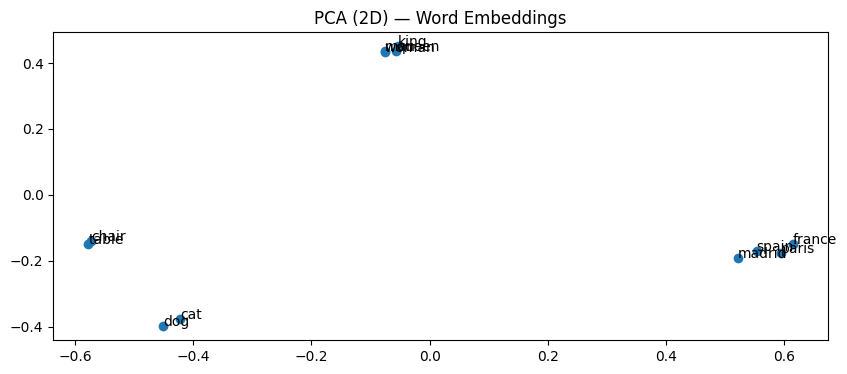

In [ ]:
plt.figure(figsize=(10,4))
plt.scatter(X_pca[:,0], X_pca[:,1])
for i, txt in enumerate(labels):
    plt.annotate(txt, (X_pca[i,0], X_pca[i,1]))
plt.title("PCA (2D) — Word Embeddings")
plt.show()

In [ ]:
# t-SNE (nota: puede tardar algo más)
from sklearn.manifold import TSNE

perp = min(5, max(2, len(labels)-1))
tsne = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    perplexity=perp,
    max_iter=1000  # antes se llamaba n_iter
)

X_tsne = tsne.fit_transform(X)

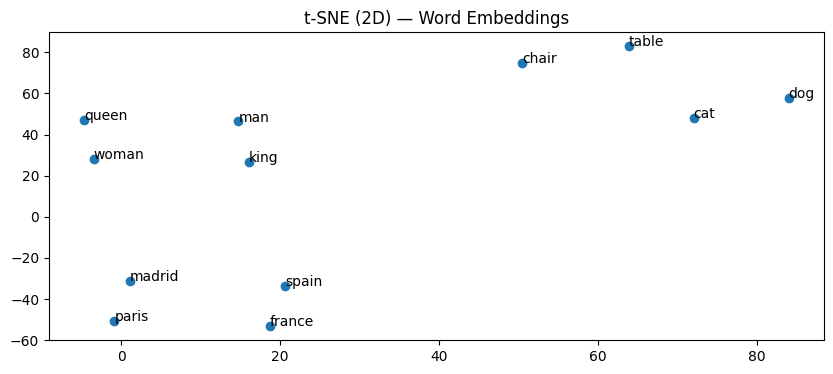

In [ ]:
plt.figure(figsize=(10,4))
plt.scatter(X_tsne[:,0], X_tsne[:,1])
for i, txt in enumerate(labels):
    plt.annotate(txt, (X_tsne[i,0], X_tsne[i,1]))
plt.title("t-SNE (2D) — Word Embeddings")
plt.show()

# B. Embeddings preentrenados
- **B) Preentrenados (descargados de internet)**: usa `gensim.downloader` para cargar modelos como
  `word2vec-google-news-300` (inglés), `glove-wiki-gigaword-100` (inglés) o `fasttext-wiki-news-subwords-300`.
arga avanzada y evaluación rápida

Si trabajas con `gensim.downloader`, prueba varios modelos (GloVe, Word2Vec, FastText) y compara:
- Similitudes de pares (`most_similar`)
- Resultados de analogías
- Calidad de agrupaciones en 2D


In [ ]:
# === Cargar embeddings preentrenados con gensim (requiere Internet) ===
# En Windows necesitamos instalar esto paquetes
# !pip install mkl mkl-service

# Descomenta y elige uno:
import gensim.downloader as api
kv = api.load("glove-wiki-gigaword-100")   # 100D, inglés
# kv = api.load("word2vec-google-news-300")  # 300D, inglés (grande)
# kv = api.load("fasttext-wiki-news-subwords-300")  # 300D, inglés (subpalabras)

In [ ]:
print(f"Vocab size: {len(kv)}  ·  Dim: {kv.vector_size}")
kv.most_similar("king")[:5]

Vocab size: 400000  ·  Dim: 100


[('prince', 0.7682328820228577),
 ('queen', 0.7507690787315369),
 ('son', 0.7020888328552246),
 ('brother', 0.6985775232315063),
 ('monarch', 0.6977890729904175)]